<a href="https://colab.research.google.com/github/vinkoff/Learner/blob/master/Unit_6_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*italicised text*# Unit 6 : The eigenfaces example: chaining PCA and SVMs

Here we’ll take a look at a simple facial recognition example. Ideally, we would use a dataset consisting of a subset of the Labeled Faces in the Wild data that is available with sklearn.datasets.fetch_lfw_people().

In [ ]:
from sklearn import datasets
faces = datasets.fetch_olivetti_faces()
faces.data.shape

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data


(400, 4096)

A loop iterates through 6 images, arranging them in a grid. The add_subplot function is employed with parameters to specify the layout of subplots (2 rows and 3 columns) and to remove tick marks. Each subplot displays an image from a dataset using a bone colormap.

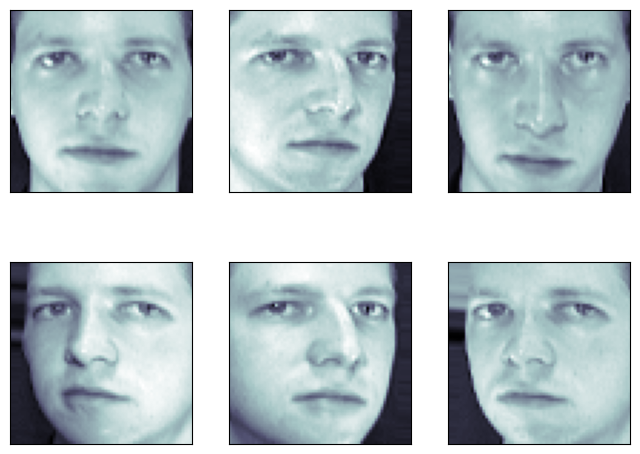

In [ ]:
from matplotlib import pyplot as plt
fig = plt.figure(figsize=(8, 6))

for i in range(6):  # Plot with 6 images
    ax = fig.add_subplot(2, 3, i + 1, xticks=[], yticks=[]) # 6 images are plotted in Row 2 and Column 3
    ax.imshow(faces.images[i], cmap=plt.cm.bone)

**1. Generate a plot with 20 images by filling the GAP in two places.**

In [ ]:
from matplotlib import pyplot as plt
fig = plt.figure(figsize=(8, 6))

for i in range(20):  # Plot with 20 images
    ax = fig.add_subplot(__, __, i + 1, xticks=[], yticks=[]) # 20 images are plotted in Row 4 and Column 5
    ax.imshow(faces.images[i], cmap=plt.cm.bone)

ValueError: ignored

<Figure size 800x600 with 0 Axes>

**2. Fill the gap to complete the code for execution correctly.**

In [ ]:
from sklearn.model_selection import train_test_split
______, X_test, y_train, y_test = train_test_split(faces.data,
        faces.target, random_state=0)


This code snippet utilizes scikit-learn's PCA (Principal Component Analysis) module. It initializes a PCA model with 150 principal components and enables data whitening. The model is then fitted to the training data (X_train) to reduce its dimensionality and capture essential patterns while whitening the data for better modeling.

**3. Fill the gap so that it initializes a PCA model with 10 principal components.**

In [ ]:
from sklearn import decomposition
pca = decomposition.PCA(n_components=___, whiten=True)

**4. Fill the gap to complete the fit() methods with training data.**

In [ ]:
pca.fit(_____)
plt.imshow(pca.mean_.reshape(faces.images[0].shape),
           cmap=plt.cm.bone)
print(pca.components_.shape)

PCA transformation is applied to both the training and testing datasets (X_train and X_test) using a previously fitted PCA model. The transformed datasets, X_train_pca and X_test_pca, contain the reduced-dimensional representations of the original data. The print statement displays the shape of the transformed training dataset, revealing its new dimensionality.

In [ ]:
X_train_pca = pca.transform(X_train)
X_test_pca = pca.______(X_test) # how to transform X_test like X_train [check how X_train is transformed]
print(X_train_pca.shape)

**5. In order to perform support-vector-machine classification on this reduced dataset, create and fit the model by filling the gaps.**

In [ ]:
from sklearn import svm
clf = ___.SVC(C=5., gamma=0.001)
clf.fit(X_train_pca, ________)    # how to fit/train the model

**6. Make the plot with 10 images simillar to the above mentioned code.**

In [ ]:
import numpy as np
fig = plt.figure(figsize=(8, 6))
for i in range(__):
    ax = fig.add_subplot(__, __, i + 1, xticks=[], yticks=[])
    ax.imshow(X_test[i].reshape(faces.images[0].shape),
              cmap=plt.cm.bone)
    y_pred = clf.predict(X_test_pca[i, np.newaxis])[0]
    color = ('black' if y_pred == y_test[i] else 'red')
    ax.set_title(y_pred, fontsize='small', color=color)

**7. Fill the gap to predict for svm classification.**

In [ ]:
import numpy as np
fig = plt.figure(figsize=(8, 6))
for i in range(20):
    ax = fig.add_subplot(5, 4, i + 1, xticks=[], yticks=[])
    ax.imshow(X_test[i].reshape(faces.images[0].shape),
              cmap=plt.cm.bone)
    y_pred = clf.________(X_test_pca[i, np.newaxis])[0]
    color = ('black' if y_pred == y_test[i] else 'red')
    ax.set_title(y_pred, fontsize='small', color=color)

                                                            
                                                          #END